# ViT Transfer Learning — Filtered NASA GLOBE Images

Same architecture as `07_transfer_learning.ipynb` (frozen ViT-B-16 encoder + trained linear head), but images are loaded from the ResNet18 cloud filter CSV rather than raw directories. Only images passing the per-class `head2_conf` threshold are used for training.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

CSV_PATH    = Path("../resources/cloud-images/NASA_GLOBE_CD/cloud_filter_results_1.csv")
IMAGES_ROOT = Path("../resources/cloud-images/NASA_GLOBE_CD/downloaded_images")

THRESHOLDS = {
    "Ac": 0.8,
    "As": 0.8,
    "Cb": 0.8,
    "Cc": 0.8,
    "Ci": 0.8,
    "Cs": 0.8,
    "Ct": 0.0,
    "Cu": 0.8,
    "Ns": 0.8,
    "Sc": 0.8,
    "St": 0.8,
}

def index_labeled_images_filtered(csv_path, thresholds, images_root, max_per_class=3000):
    df = pd.read_csv(csv_path)
    # normalise column names from older CSV versions
    df = df.rename(columns={"cloud_conf": "head2_conf", "head1_class": "head1_pred"})
    labeled_images = {}
    for folder, thresh in thresholds.items():
        clean = df[(df["folder"] == folder) & (df["head2_conf"] >= thresh)].head(max_per_class)
        for _, row in clean.iterrows():
            labeled_images[row["filename"]] = {
                "label": folder,
                "path":  str(Path(images_root) / folder / row["filename"]),
            }
    return labeled_images

labeled_images = index_labeled_images_filtered(CSV_PATH, THRESHOLDS, IMAGES_ROOT)

# per-class count summary
from collections import Counter
counts = Counter(v["label"] for v in labeled_images.values())
for folder in sorted(counts):
    print(f"  {folder:6s}  {counts[folder]:,}")
print(f"  {'TOTAL':6s}  {sum(counts.values()):,}")

  Ac      3,000
  As      3,000
  Cb      3,000
  Cc      3,000
  Ci      3,000
  Cs      3,000
  Ct      200
  Cu      3,000
  Ns      3,000
  Sc      3,000
  St      3,000
  TOTAL   30,200


In [2]:
def extract_labels(labeled_images):
    paths, labels = [], []
    for image_name in labeled_images:
        paths.append(labeled_images[image_name]["path"])
        labels.append(labeled_images[image_name]["label"])
    return paths, np.array(labels)

paths, labels = extract_labels(labeled_images)

In [3]:
import torch

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"device: {device}")

device: mps


In [4]:
import torchvision.transforms.v2 as T
from torchvision.transforms.v2 import InterpolationMode

IMG_SIZE = (384, 384)  # required by ViT_B_16 SWAG weights
MAX_FRAC = 0.14

border_translation = T.RandomAffine(
    degrees=0,
    translate=(MAX_FRAC, MAX_FRAC),
    interpolation=InterpolationMode.BILINEAR,
    fill=0
)

wrap_translation = T.Lambda(lambda x: torch.roll(
    x,
    shifts=(
        int(torch.randint(-int(MAX_FRAC * x.shape[-2]), int(MAX_FRAC * x.shape[-2]) + 1, (1,)).item()),
        int(torch.randint(-int(MAX_FRAC * x.shape[-1]), int(MAX_FRAC * x.shape[-1]) + 1, (1,)).item()),
    ),
    dims=(-2, -1),
))

stacked = T.Compose([
    T.RandomChoice([wrap_translation, border_translation]),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.15),
    T.RandomAffine(
        degrees=20, scale=(0.90, 1.10),
        interpolation=InterpolationMode.BILINEAR, fill=0
    ),
    T.RandomResizedCrop(
        size=IMG_SIZE, scale=(0.80, 1.00), ratio=(0.90, 1.10),
        interpolation=InterpolationMode.BILINEAR
    ),
])

one_of = T.RandomChoice([
    wrap_translation,
    border_translation,
    T.RandomChoice([T.RandomHorizontalFlip(p=1.0), T.RandomVerticalFlip(p=1.0)]),
    T.RandomRotation(degrees=20, interpolation=InterpolationMode.BILINEAR, fill=0),
])

normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_transforms = T.Compose([
    T.Resize(IMG_SIZE, interpolation=InterpolationMode.BILINEAR),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.RandomChoice([stacked, one_of]),
    normalize,
])

eval_transforms = T.Compose([
    T.Resize(IMG_SIZE, interpolation=InterpolationMode.BILINEAR),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    normalize,
])

In [5]:
import torchvision
import torch.nn as nn

weights = torchvision.models.ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1
model = torchvision.models.vit_b_16(weights=weights).to(device)
print("ViT-B-16 loaded")

ViT-B-16 loaded


In [6]:
from sklearn.preprocessing import LabelEncoder

def encode_labels(labels):
    ordinal_encoder = LabelEncoder()
    encoded_labels = ordinal_encoder.fit_transform(labels)
    return encoded_labels, ordinal_encoder.classes_

encoded_labels, class_names = encode_labels(labels)
print(f"Classes ({len(class_names)}): {class_names}")

Classes (11): ['Ac' 'As' 'Cb' 'Cc' 'Ci' 'Cs' 'Ct' 'Cu' 'Ns' 'Sc' 'St']


In [7]:
from torch.utils.data import Dataset
from sklearn.model_selection import StratifiedShuffleSplit
from PIL import Image

class MyImages(Dataset):
    def __init__(self, paths, encoded_labels, split="train", test_size=0.2, val_size=0.1,
                 random_state=42, transform=None, split_indices=None):
        if split not in {None, "train", "val", "test"}:
            raise ValueError(f"split must be one of {{'None','train','val','test'}}, got {split!r}")

        self.transform = transform
        paths = np.array(list(paths))
        encoded_labels = np.array(list(encoded_labels))

        if split_indices is None:
            sss1 = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
            trainval_idx, test_idx = next(sss1.split(paths, encoded_labels))

            val_within_trainval = val_size / (1.0 - test_size)
            sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_within_trainval, random_state=random_state)
            train_rel_idx, val_rel_idx = next(sss2.split(paths[trainval_idx], encoded_labels[trainval_idx]))

            split_indices = {
                "train": trainval_idx[train_rel_idx],
                "val":   trainval_idx[val_rel_idx],
                "test":  test_idx,
            }

        idx = split_indices[split]
        self.paths = paths[idx].tolist()
        self.encoded_labels = encoded_labels[idx].tolist()

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.encoded_labels[idx]


paths_arr  = np.array(list(paths))
labels_arr = np.array(list(encoded_labels))

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
trainval_idx, test_idx = next(sss1.split(paths_arr, labels_arr))

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.1/0.8, random_state=42)
train_rel_idx, val_rel_idx = next(sss2.split(paths_arr[trainval_idx], labels_arr[trainval_idx]))

split_indices = {
    "train": trainval_idx[train_rel_idx],
    "val":   trainval_idx[val_rel_idx],
    "test":  test_idx,
}

train_set = MyImages(paths=paths, encoded_labels=encoded_labels,
                     split="train", transform=train_transforms,
                     split_indices=split_indices)
valid_set = MyImages(paths=paths, encoded_labels=encoded_labels,
                     split="val",   transform=eval_transforms,
                     split_indices=split_indices)
test_set  = MyImages(paths=paths, encoded_labels=encoded_labels,
                     split="test",  transform=eval_transforms,
                     split_indices=split_indices)

print(f"train: {len(train_set):,}  val: {len(valid_set):,}  test: {len(test_set):,}")

train: 21,140  val: 3,020  test: 6,040


In [8]:
from torch.utils.data import DataLoader, WeightedRandomSampler

train_labels_list = [train_set.encoded_labels[i] for i in range(len(train_set))]
class_counts  = np.bincount(train_labels_list)
class_weights = 1.0 / class_counts
sample_weights = torch.tensor([class_weights[l] for l in train_labels_list], dtype=torch.float)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_set, batch_size=32, sampler=sampler, num_workers=4, pin_memory=False)
valid_loader = DataLoader(valid_set, batch_size=32, num_workers=4, pin_memory=False)
test_loader  = DataLoader(test_set,  batch_size=32, num_workers=4, pin_memory=False)

In [9]:
n_classes = len(class_names)  # 11
model.heads = nn.Sequential(nn.Dropout(p=0.1), nn.Linear(768, n_classes)).to(device)

for param in model.parameters():
    param.requires_grad = False
for param in model.heads.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Trainable params: 8,459 / 86,098,955


In [10]:
import os
from tqdm.auto import tqdm

FEATURES_PATH = "cached_features_filtered"
os.makedirs(FEATURES_PATH, exist_ok=True)

def extract_features(model, loader, device):
    model.eval()
    all_features, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader):
            imgs = imgs.to(device)
            x = model._process_input(imgs)
            n = x.shape[0]
            batch_class_token = model.class_token.expand(n, -1, -1)
            x = torch.cat([batch_class_token, x], dim=1)
            x = model.encoder(x)
            x = x[:, 0]  # 768-dim class token
            all_features.append(x.cpu())
            all_labels.append(labels)
    return torch.cat(all_features), torch.cat(all_labels)

if not os.path.exists(f"{FEATURES_PATH}/train.pt"):
    extract_train_loader = DataLoader(train_set, batch_size=32, num_workers=0)
    extract_valid_loader = DataLoader(valid_set, batch_size=32, num_workers=0)
    extract_test_loader  = DataLoader(test_set,  batch_size=32, num_workers=0)

    print("Extracting train features...")
    train_feats, train_feat_labels = extract_features(model, extract_train_loader, device)
    torch.save({"features": train_feats, "labels": train_feat_labels}, f"{FEATURES_PATH}/train.pt")

    print("Extracting val features...")
    val_feats, val_feat_labels = extract_features(model, extract_valid_loader, device)
    torch.save({"features": val_feats, "labels": val_feat_labels}, f"{FEATURES_PATH}/val.pt")

    print("Extracting test features...")
    test_feats, test_feat_labels = extract_features(model, extract_test_loader, device)
    torch.save({"features": test_feats, "labels": test_feat_labels}, f"{FEATURES_PATH}/test.pt")

    print(f"Done. Train: {train_feats.shape}, Val: {val_feats.shape}, Test: {test_feats.shape}")
else:
    print("Cached features found, skipping extraction.")

/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Extracting train features...


100%|██████████| 661/661 [15:41<00:00,  1.42s/it]


Extracting val features...


100%|██████████| 95/95 [02:06<00:00,  1.33s/it]


Extracting test features...


100%|██████████| 189/189 [04:12<00:00,  1.34s/it]

Done. Train: torch.Size([21140, 768]), Val: torch.Size([3020, 768]), Test: torch.Size([6040, 768])


In [11]:
from torch.utils.data import TensorDataset

train_data = torch.load(f"{FEATURES_PATH}/train.pt", weights_only=True)
val_data   = torch.load(f"{FEATURES_PATH}/val.pt",   weights_only=True)
test_data  = torch.load(f"{FEATURES_PATH}/test.pt",  weights_only=True)

feat_train_set = TensorDataset(train_data["features"], train_data["labels"])
feat_val_set   = TensorDataset(val_data["features"],   val_data["labels"])
feat_test_set  = TensorDataset(test_data["features"],  test_data["labels"])

feat_class_counts   = np.bincount(train_data["labels"].numpy())
feat_class_weights  = 1.0 / feat_class_counts
feat_sample_weights = torch.tensor(
    [feat_class_weights[l] for l in train_data["labels"].numpy()], dtype=torch.float
)
feat_sampler = WeightedRandomSampler(feat_sample_weights, len(feat_sample_weights), replacement=True)

feat_train_loader = DataLoader(feat_train_set, batch_size=256, sampler=feat_sampler)
feat_valid_loader = DataLoader(feat_val_set,   batch_size=256)
feat_test_loader  = DataLoader(feat_test_set,  batch_size=256)

In [12]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs, patience=20, checkpoint_path="best_model.pt"):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    best_val = 0.0
    epochs_without_improvement = 0

    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)

        train_loss = total_loss / len(train_loader)
        train_acc  = metric.compute().item()
        val_acc    = evaluate_tm(model, valid_loader, metric).item()

        history["train_losses"].append(train_loss)
        history["train_metrics"].append(train_acc)
        history["valid_metrics"].append(val_acc)

        print(f"Epoch {epoch + 1}/{n_epochs} | "
              f"loss: {train_loss:.4f} | "
              f"train: {train_acc:.4f} | "
              f"val: {val_acc:.4f}"
              + (" *" if val_acc > best_val else ""))

        if val_acc > best_val:
            best_val = val_acc
            epochs_without_improvement = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch + 1} (best val: {best_val:.4f})")
                break

    model.load_state_dict(torch.load(checkpoint_path, weights_only=True))
    return history

In [13]:
n_epochs  = 300
optimizer = torch.optim.AdamW(model.heads.parameters())
xentropy  = nn.CrossEntropyLoss()
accuracy  = torchmetrics.Accuracy(task="multiclass", num_classes=n_classes).to(device)

history = train(
    model.heads, optimizer, xentropy, accuracy,
    feat_train_loader, feat_valid_loader,
    n_epochs, patience=100,
    checkpoint_path="best_model_filtered.pt",
)

test_acc = evaluate_tm(model.heads, feat_test_loader, accuracy)
print(f"\nTest accuracy: {test_acc:.4f}")

Epoch 1/300 | loss: 1.7975 | train: 0.3604 | val: 0.3629 *
Epoch 2/300 | loss: 1.5675 | train: 0.4423 | val: 0.3884 *
Epoch 3/300 | loss: 1.5164 | train: 0.4588 | val: 0.3854
Epoch 4/300 | loss: 1.4925 | train: 0.4724 | val: 0.3990 *
Epoch 5/300 | loss: 1.4528 | train: 0.4905 | val: 0.4142 *
Epoch 6/300 | loss: 1.4403 | train: 0.4853 | val: 0.4089
Epoch 7/300 | loss: 1.4384 | train: 0.4895 | val: 0.4119
Epoch 8/300 | loss: 1.4328 | train: 0.4937 | val: 0.4268 *
Epoch 9/300 | loss: 1.4306 | train: 0.4942 | val: 0.4162
Epoch 10/300 | loss: 1.4010 | train: 0.5080 | val: 0.4232
Epoch 11/300 | loss: 1.4073 | train: 0.5035 | val: 0.4192
Epoch 12/300 | loss: 1.4018 | train: 0.5031 | val: 0.4162
Epoch 13/300 | loss: 1.4141 | train: 0.4973 | val: 0.4119
Epoch 14/300 | loss: 1.4068 | train: 0.5085 | val: 0.4172
Epoch 15/300 | loss: 1.3877 | train: 0.5107 | val: 0.4288 *
Epoch 16/300 | loss: 1.3967 | train: 0.5027 | val: 0.4364 *
Epoch 17/300 | loss: 1.3899 | train: 0.5076 | val: 0.4272
Epoch 18/

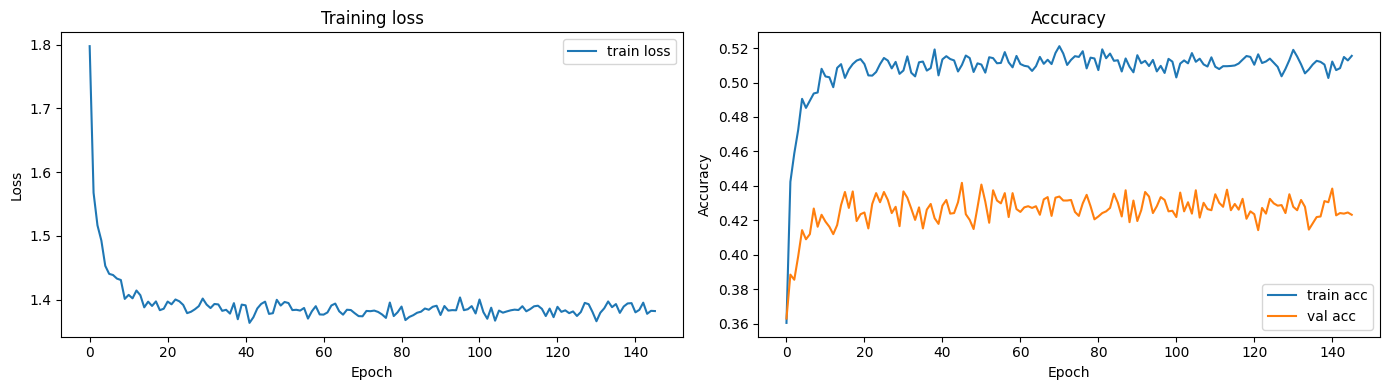

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history["train_losses"], label="train loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training loss")
axes[0].legend()

axes[1].plot(history["train_metrics"], label="train acc")
axes[1].plot(history["valid_metrics"], label="val acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()